In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------------
# Domain & sampling (linspace + fixed step)
# --------------------------------------------------
axmax = 2.0
dx = 0.1
n_points = int((2*axmax)/dx) + 1
x = np.linspace(-axmax, axmax, n_points)
y = np.linspace(-axmax, axmax, n_points)
z = np.linspace(-axmax, axmax, n_points)

# 3D grid
X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

# --------------------------------------------------
# Effective Kepler potential: Phi(r) = -C/r + L^2/r^2
# --------------------------------------------------
C = 1.0
L = 1.10

r = np.sqrt(X**2 + Y**2 + Z**2)
eps = 1e-9                 # avoid division by zero at r=0 (singularity)
r_safe = np.maximum(r, eps)

Phi = C / r_safe - (L**2) / (r_safe**2)

# Analytical gradient:
# ∇Phi = -(C/r^3 - 2L^2/r^4) * (x, y, z)
common = (C / (r_safe**3)) - (2.0 * (L**2) / (r_safe**4))
dPhidx_analytic = common * X
dPhidy_analytic = common * Y
dPhidz_analytic = common * Z

# --------------------------------------------------
# Numerical gradient (np.gradient returns d/dy, d/dx, d/dz in array order [y,x,z])
# --------------------------------------------------
dy, dx, dz = (y[1]-y[0]), (x[1]-x[0]), (z[1]-z[0])
dPhi_dy, dPhi_dx, dPhi_dz = np.gradient(Phi, dy, dx, dz)
dfx_num = dPhi_dx
dfy_num = dPhi_dy
dfz_num = dPhi_dz

# --------------------------------------------------
# Choose a z-slice
# --------------------------------------------------
m = n_points//2 + 18
m = min(m, n_points-1)     # safety clamp
z_m = z[m]


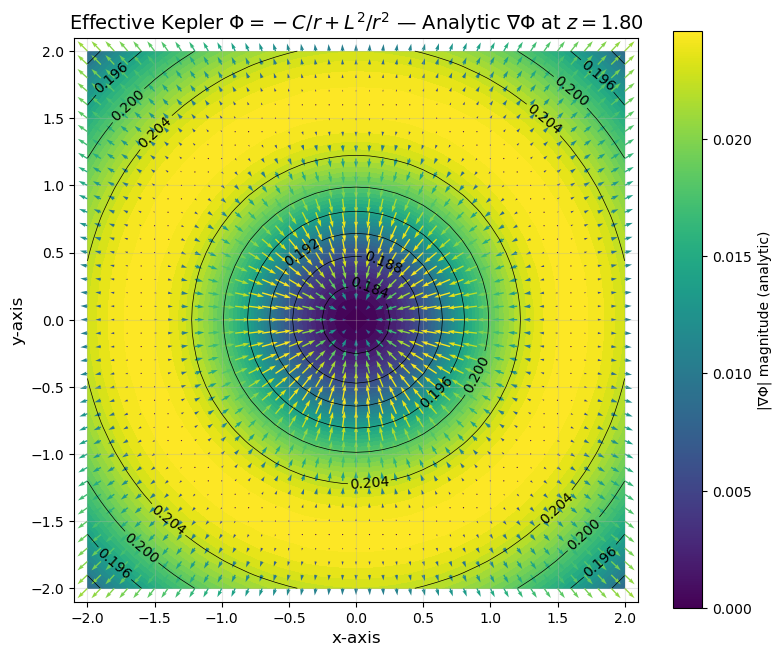

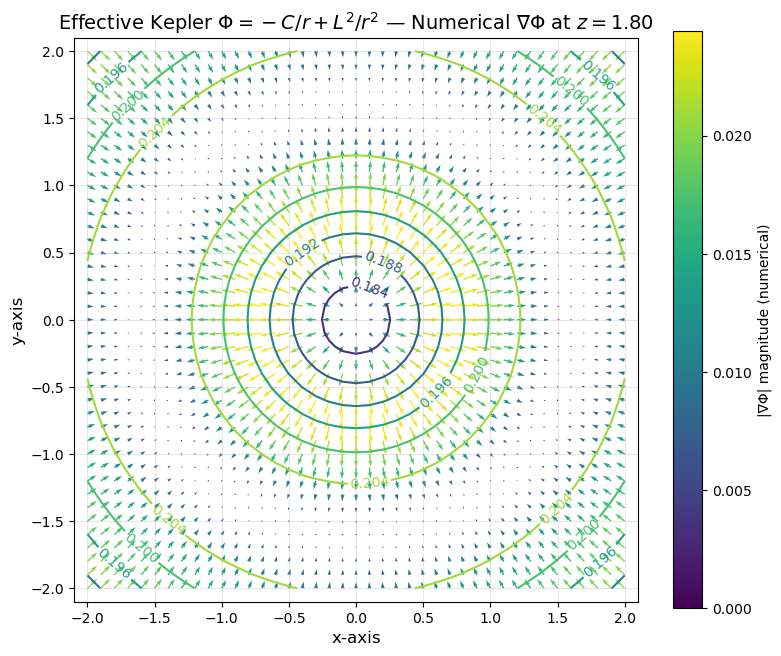

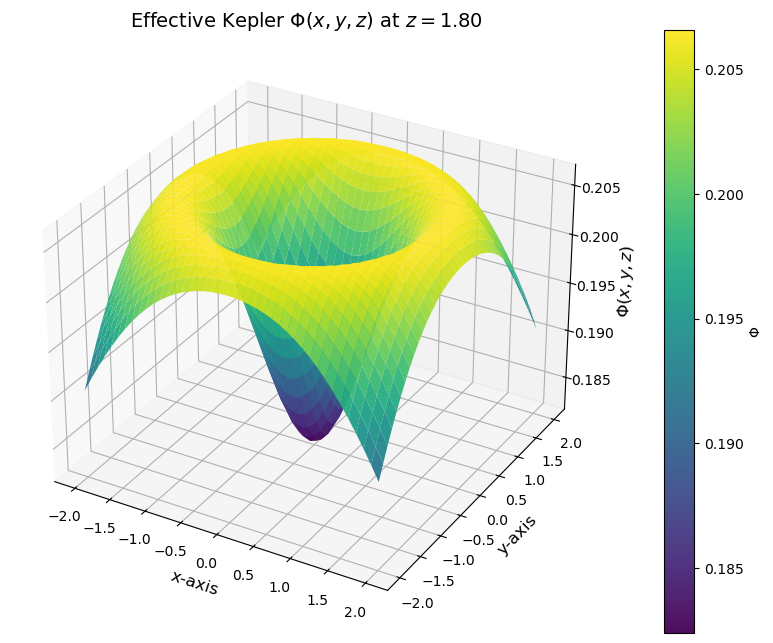

In [6]:
# --------------------------------------------------
# 1) Analytic gradient: contour + quiver (magnitude-colored)
# --------------------------------------------------
plt.figure(figsize=(8, 7))

CS = plt.contour(X[:, :, m], Y[:, :, m], Phi[:, :, m], colors="k", linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10)

U = dPhidx_analytic[:, :, m]
V = dPhidy_analytic[:, :, m]
mag = np.hypot(U, V)

cf = plt.contourf(
    X[:, :, m], Y[:, :, m], Phi[:, :, m],
    levels=40, cmap="viridis", extend="both"
)

q = plt.quiver(
    X[:, :, m], Y[:, :, m],
    U, V,
    mag, cmap="viridis",
    angles='xy', scale_units='xy', scale=0.2, pivot='tail'
)
plt.colorbar(q, label="|∇Φ| magnitude (analytic)", shrink=0.9)

plt.xlabel('x-axis', fontsize=12)
plt.ylabel('y-axis', fontsize=12)
plt.title(rf'Effective Kepler $\Phi=-C/r+L^2/r^2$ — Analytic $\nabla \Phi$ at $z={z_m:.2f}$', fontsize=14)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(1.05*x.min(), 1.05*x.max())
plt.ylim(1.05*y.min(), 1.05*y.max())
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) Numerical gradient: contour + quiver (magnitude-colored)
# --------------------------------------------------
plt.figure(figsize=(8, 7))

CS2 = plt.contour(X[:, :, m], Y[:, :, m], Phi[:, :, m], cmap="viridis")
plt.clabel(CS2, inline=True, fontsize=10)

U_num = dfx_num[:, :, m]
V_num = dfy_num[:, :, m]
mag_num = np.hypot(U_num, V_num)

q2 = plt.quiver(
    X[:, :, m], Y[:, :, m],
    U_num, V_num,
    mag_num, cmap="viridis",
    angles='xy', scale_units='xy', scale=0.2, pivot='tail'
)
plt.colorbar(q2, label="|∇Φ| magnitude (numerical)", shrink=0.9)

plt.xlabel('x-axis', fontsize=12)
plt.ylabel('y-axis', fontsize=12)
plt.title(rf'Effective Kepler $\Phi=-C/r+L^2/r^2$ — Numerical $\nabla \Phi$ at $z={z_m:.2f}$', fontsize=14)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(1.05*x.min(), 1.05*x.max())
plt.ylim(1.05*y.min(), 1.05*y.max())
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3) 3D surface (same z-slice), with viridis + colorbar
# --------------------------------------------------
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X[:, :, m], Y[:, :, m], Phi[:, :, m],
    cmap="viridis",
    linewidth=0, antialiased=True, alpha=0.95
)

ax.set_xlabel('x-axis', fontsize=12)
ax.set_ylabel('y-axis', fontsize=12)
ax.set_zlabel(r'$\Phi(x,y,z)$', fontsize=12)
ax.set_title(rf'Effective Kepler $\Phi(x,y,z)$ at $z={z_m:.2f}$', fontsize=14)

fig.colorbar(surf, shrink=0.9, pad=0.08, label=r'$\Phi$')
plt.tight_layout()
plt.show()
